Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded")

Libraries loaded


Loading Data

In [3]:
sales = pd.read_csv("data/sales_data.csv")
house = pd.read_csv("data/house_prices.csv")
churn = pd.read_csv("data/customer_churn.csv")

sales.shape, house.shape, churn.shape

((100, 7), (300, 8), (500, 9))

Preview

In [4]:
sales.head()
house.head()
churn.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


Information(Info)

In [5]:
sales.info()
house.info()
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-nu

Missing Values

In [6]:
sales.isnull().sum()
house.isnull().sum()
churn.isnull().sum()

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Cleaning

In [7]:
sales["Date"] = pd.to_datetime(sales["Date"])

Feature Engineering

In [8]:
sales["Revenue_Category"] = pd.cut(
    sales["Total_Sales"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

Sales Distribution

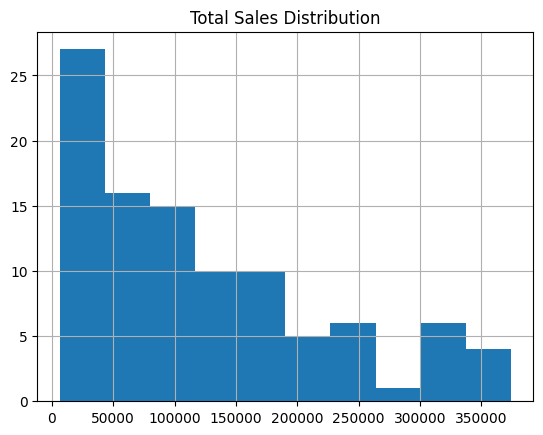

In [9]:
plt.figure()
sales["Total_Sales"].hist()
plt.title("Total Sales Distribution")
plt.show()

Sales by Region

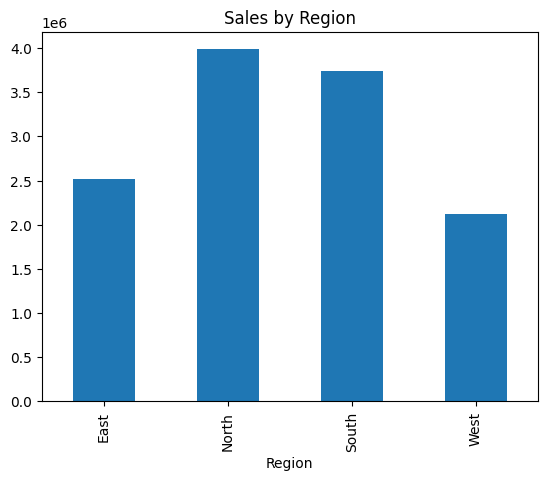

In [10]:
sales.groupby("Region")["Total_Sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.show()

House Price Distribution

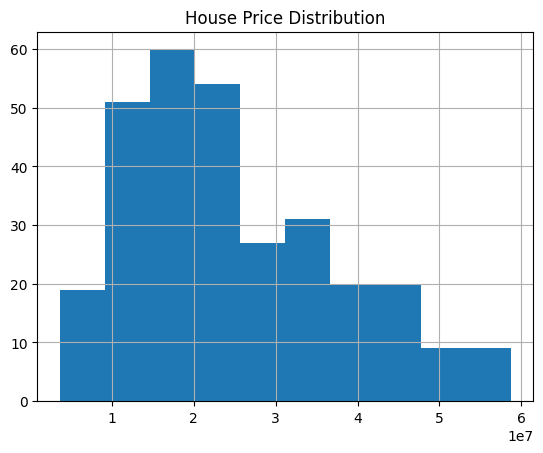

In [11]:
plt.figure()
house["Price"].hist()
plt.title("House Price Distribution")
plt.show()

Area vs Price

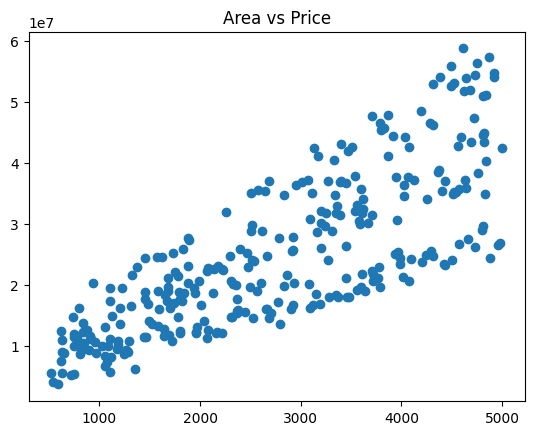

In [12]:
plt.figure()
plt.scatter(house["Area"], house["Price"])
plt.title("Area vs Price")
plt.show()

Churn Count

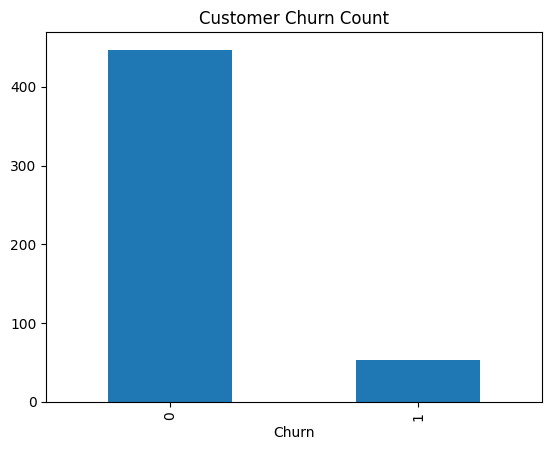

In [13]:
churn["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Count")
plt.show()

Churn Rate

In [14]:
churn_rate = churn["Churn"].mean()*100
churn_rate

np.float64(10.6)

Contract Analysis

In [15]:
churn.groupby("Contract")["MonthlyCharges"].mean()

Contract
Month-to-month    112.829412
One year          114.005376
Two year          114.111111
Name: MonthlyCharges, dtype: float64

Property Type Analysis

In [16]:
house.groupby("Property_Type")["Price"].mean()

Property_Type
Apartment    2.712420e+07
House        2.287692e+07
Villa        2.498985e+07
Name: Price, dtype: float64

KPI Metrics

In [17]:
total_revenue = sales["Total_Sales"].sum()
avg_house_price = house["Price"].mean()

total_revenue, avg_house_price

(np.int64(12365048), np.float64(24883658.333333332))

Validation Tests

In [18]:
assert sales["Total_Sales"].min() >= 0
assert churn["Churn"].isin([0,1]).all()
assert house["Price"].min() > 0

print("All tests passed")

All tests passed


Save Cleaned Files

In [19]:
sales.to_csv("data/cleaned_sales.csv", index=False)
house.to_csv("data/cleaned_house.csv", index=False)
churn.to_csv("data/cleaned_churn.csv", index=False)

Final Summary

In [20]:
print("===== BUSINESS SUMMARY =====")
print("Total Revenue:", total_revenue)
print("Average House Price:", avg_house_price)
print("Churn Rate:", round(churn_rate,2), "%")

===== BUSINESS SUMMARY =====
Total Revenue: 12365048
Average House Price: 24883658.333333332
Churn Rate: 10.6 %
